In [ ]:
import numpy as np
import glob
import os
from datetime import datetime
from datetime import timedelta
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from netCDF4 import Dataset
from wrf import getvar
import pickle
import matplotlib.dates as mdates

import pandas as pd
from matplotlib.lines import Line2D

ERROR 1: PROJ: proj_create_from_database: Open of /g/data/xp65/public/./apps/med_conda/envs/analysis3-25.09/share/proj failed
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/wrf/__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Plot time series of temperature and relative humidity differences between the scenarios for all times and grids - Figure 5 and S7

In [ ]:
#load instantaneous T and RH differences of experiments with Geoscape 
#see the calculation of the differences at the bottom of the code
with open("/g/data/gb02/mf9078/WRF_Tdiffscatter.pkl", "rb") as f:
    diff_data_T=pickle.load(f)

with open("/g/data/gb02/mf9078/WRF_RHdiffscatter.pkl", "rb") as f:
    diff_data_RH=pickle.load(f)

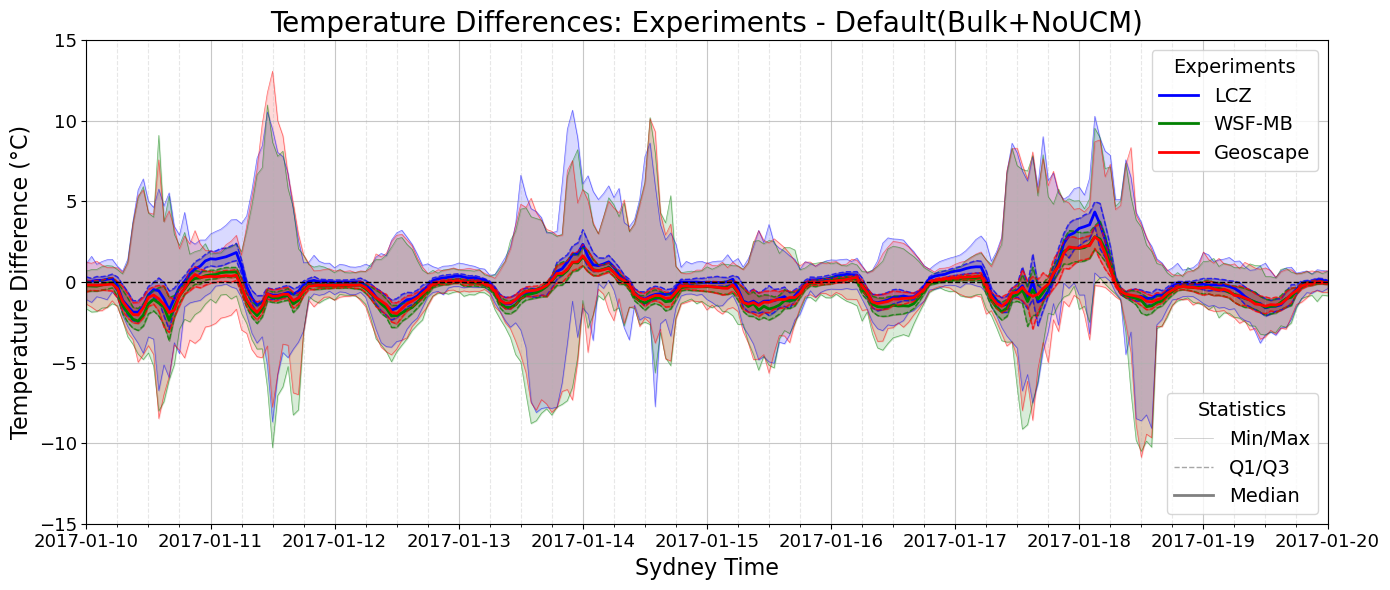

In [6]:
#T differences with Default (max-min range and the quartiles)
# Define experiments and colors for plotting
experiments = ["LCZ", "WSF-MB", "Geoscape"]
colors = {'LCZ': 'blue', 'WSF-MB': 'green', 'Geoscape': 'red'}

# Create legend handles (shared between both figures)
experiment_handles = []  # Initialize as a list
for exp in experiments:
    experiment_handles.append(Line2D([0], [0], color=colors[exp], linewidth=2, label=exp))

line_type_handles = [
    Line2D([0], [0], color='gray', linewidth=0.5, alpha=0.5, label='Min/Max'),
    Line2D([0], [0], color='gray', linewidth=1, alpha=0.7, linestyle='--', label='Q1/Q3'),
    Line2D([0], [0], color='gray', linewidth=2, label='Median')
]

# ============ Temperature Differences Plot ============
fig1, ax1 = plt.subplots(1, 1, figsize=(14, 6))

for exp in experiments:
    times_list = []
    min_vals = []
    q1_vals = []
    median_vals = []
    q3_vals = []
    max_vals = []
    
    for i in range(len(diff_data_T[exp])):
        # Get the data array for this time step
        data_array = diff_data_T[exp][i]
        
        # Extract all non-NaN values (flatten the spatial dimensions)
        non_nan_values = data_array.values[~np.isnan(data_array.values)]
        
        if len(non_nan_values) > 0:
            # Get the corresponding timestamp
            timestamp = diff_data_T['time'][i]
            times_list.append(timestamp)
            
            # Calculate statistics
            min_vals.append(np.min(non_nan_values))
            q1_vals.append(np.percentile(non_nan_values, 25))
            median_vals.append(np.percentile(non_nan_values, 50))
            q3_vals.append(np.percentile(non_nan_values, 75))
            max_vals.append(np.max(non_nan_values))
    
    # Plot shaded regions
    ax1.fill_between(times_list, min_vals, q1_vals, alpha=0.15, color=colors[exp])
    ax1.fill_between(times_list, q1_vals, q3_vals, alpha=0.35, color=colors[exp])
    ax1.fill_between(times_list, q3_vals, max_vals, alpha=0.15, color=colors[exp])
    
    # Plot the 5 lines
    ax1.plot(times_list, min_vals, color=colors[exp], linewidth=0.5, alpha=0.5)
    ax1.plot(times_list, q1_vals, color=colors[exp], linewidth=1, alpha=0.7, linestyle='--')
    ax1.plot(times_list, median_vals, color=colors[exp], linewidth=2, label=exp)
    ax1.plot(times_list, q3_vals, color=colors[exp], linewidth=1, alpha=0.7, linestyle='--')
    ax1.plot(times_list, max_vals, color=colors[exp], linewidth=0.5, alpha=0.5)

ax1.set_xlabel('Sydney Time', fontsize=16)
ax1.set_ylabel('Temperature Difference (°C)', fontsize=16)
ax1.set_xlim(pd.to_datetime("2017-01-10"), pd.to_datetime("2017-01-20"))
ax1.set_ylim(-15, 15)
plt.yticks(fontsize=13)
ax1.set_title('Temperature Differences: Experiments - Default(Bulk+NoUCM)', fontsize=20) #, fontweight='bold'

# Add legends
first_legend = ax1.legend(handles=experiment_handles, loc='upper right', title='Experiments', fontsize=14, title_fontsize=14)
ax1.add_artist(first_legend)
ax1.legend(handles=line_type_handles, loc='lower right', title='Statistics', fontsize=14, title_fontsize=14)

ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='black', linestyle='--', linewidth=1)

#ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax1.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
ax1.grid(True, which='minor', linestyle='--', alpha=0.3)  # 6-hourly
ax1.grid(True, which='major', linestyle='-', alpha=0.7)   # daily

# Rotate x-axis labels for better readability
plt.setp(ax1.xaxis.get_majorticklabels(), fontsize=13) #, rotation=45, ha='right'

plt.tight_layout()
plt.savefig("TemperatureDiff.png", dpi=300, bbox_inches='tight')
plt.show()


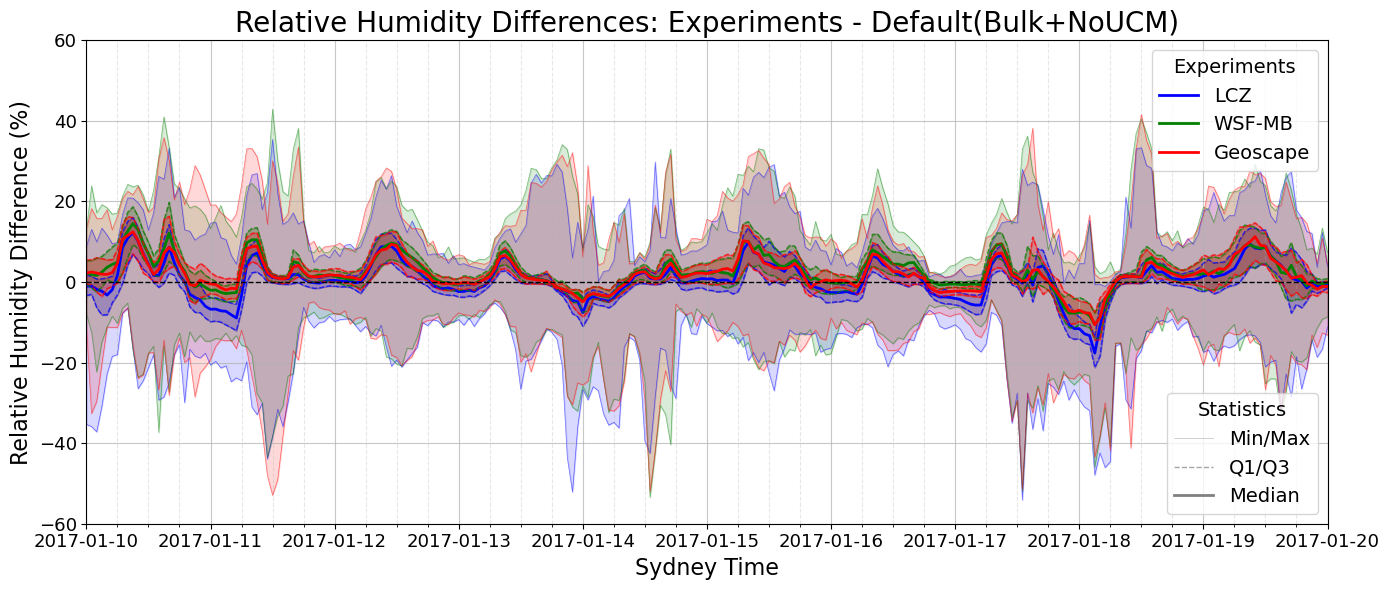

In [7]:
# ============ RH Differences Plot ============
fig1, ax1 = plt.subplots(1, 1, figsize=(14, 6))

for exp in experiments:
    times_list = []
    min_vals = []
    q1_vals = []
    median_vals = []
    q3_vals = []
    max_vals = []
    
    for i in range(len(diff_data_RH[exp])):
        # Get the data array for this time step
        data_array = diff_data_RH[exp][i]
        
        # Extract all non-NaN values (flatten the spatial dimensions)
        non_nan_values = data_array.values[~np.isnan(data_array.values)]
        
        if len(non_nan_values) > 0:
            # Get the corresponding timestamp
            timestamp = diff_data_RH['time'][i]
            times_list.append(timestamp)
            
            # Calculate statistics
            min_vals.append(np.min(non_nan_values))
            q1_vals.append(np.percentile(non_nan_values, 25))
            median_vals.append(np.percentile(non_nan_values, 50))
            q3_vals.append(np.percentile(non_nan_values, 75))
            max_vals.append(np.max(non_nan_values))
    
    # Plot shaded regions
    ax1.fill_between(times_list, min_vals, q1_vals, alpha=0.15, color=colors[exp])
    ax1.fill_between(times_list, q1_vals, q3_vals, alpha=0.35, color=colors[exp])
    ax1.fill_between(times_list, q3_vals, max_vals, alpha=0.15, color=colors[exp])
    
    # Plot the 5 lines
    ax1.plot(times_list, min_vals, color=colors[exp], linewidth=0.5, alpha=0.5)
    ax1.plot(times_list, q1_vals, color=colors[exp], linewidth=1, alpha=0.7, linestyle='--')
    ax1.plot(times_list, median_vals, color=colors[exp], linewidth=2, label=exp)
    ax1.plot(times_list, q3_vals, color=colors[exp], linewidth=1, alpha=0.7, linestyle='--')
    ax1.plot(times_list, max_vals, color=colors[exp], linewidth=0.5, alpha=0.5)

ax1.set_xlabel('Sydney Time', fontsize=16)
ax1.set_ylabel('Relative Humidity Difference (%)', fontsize=16)
ax1.set_xlim(pd.to_datetime("2017-01-10"), pd.to_datetime("2017-01-20"))
ax1.set_ylim(-60, 60)
plt.yticks(fontsize=13)
ax1.set_title('Relative Humidity Differences: Experiments - Default(Bulk+NoUCM)', fontsize=20) #, fontweight='bold'

# Add legends
first_legend = ax1.legend(handles=experiment_handles, loc='upper right', title='Experiments', fontsize=14, title_fontsize=14)
ax1.add_artist(first_legend)
ax1.legend(handles=line_type_handles, loc='lower right', title='Statistics', fontsize=14, title_fontsize=14)

ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='black', linestyle='--', linewidth=1)

#ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax1.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
ax1.grid(True, which='minor', linestyle='--', alpha=0.3)  # 6-hourly
ax1.grid(True, which='major', linestyle='-', alpha=0.7)   # daily

# Rotate x-axis labels for better readability
plt.setp(ax1.xaxis.get_majorticklabels(), fontsize=13) #, rotation=45, ha='right'

plt.tight_layout()
plt.savefig("RHDiff.png", dpi=300, bbox_inches='tight')
plt.show()

Plot the location of top 10 temperature and relative humidity differences between scenarios - Figure S8 and Table S7

In [ ]:
def find_top_differences(diff_data, exp_list, var_name='T'):
    """
    Find top 10 grid points with highest absolute differences for each experiment.
    
    Parameters:
    -----------
    diff_data : dict
        Dictionary containing difference data for each experiment
    exp_list : list or set
        List of experiment names
    var_name : str
        Variable name ('T' or 'RH2')
    
    Returns:
    --------
    results_df : dict
        Dictionary with DataFrames for each experiment showing top 5 locations
    """
    results = {}
    
    for exp in exp_list:
        print(f"\n{'='*60}")
        print(f"Processing {exp} - {var_name}")
        print(f"{'='*60}")
        
        # Store all non-NaN values with their metadata
        all_diffs = []
        
        for i, time in enumerate(diff_data['time']):
            data = diff_data[exp][i]
            
            # Get absolute differences
            abs_diff = np.abs(data.values)
            
            # Find non-NaN locations
            non_nan_mask = ~np.isnan(abs_diff)
            
            if non_nan_mask.any():
                # Get indices of non-NaN values
                non_nan_indices = np.where(non_nan_mask)
                
                # Extract XLAT and XLONG coordinates
                xlat_vals = data['XLAT'].values[non_nan_indices]
                xlong_vals = data['XLONG'].values[non_nan_indices]
                diff_vals = abs_diff[non_nan_indices]
                
                # Store each point
                for j in range(len(diff_vals)):
                    all_diffs.append({
                        'time': time,
                        'XLAT': xlat_vals[j],
                        'XLONG': xlong_vals[j],
                        'abs_diff': diff_vals[j],
                        'south_north_idx': non_nan_indices[0][j],
                        'west_east_idx': non_nan_indices[1][j]
                    })
        
        # Convert to DataFrame and sort
        df = pd.DataFrame(all_diffs)
        df_sorted = df.sort_values('abs_diff', ascending=False)
        
        # Get top 10
        top_10 = df_sorted.head(10).reset_index(drop=True)


        #results[exp] = top_10
        results[exp] = top_10
        
        # Print results
        print(f"\nTop 10 grid points with highest |{var_name}| differences:")
        print("-" * 60)
        for idx, row in top_10.iterrows():
            print(f"\nRank {idx+1}:")
            print(f"  Time: {row['time']}")
            print(f"  XLAT: {row['XLAT']:.4f}")
            print(f"  XLONG: {row['XLONG']:.4f}")
            print(f"  Absolute Difference: {row['abs_diff']:.4f}")
            print(f"  Grid indices: south_north={row['south_north_idx']}, west_east={row['west_east_idx']}")
    
    return results

# Find top differences for Temperature
print("\n" + "="*70)
print("TEMPERATURE DIFFERENCES")
print("="*70)
top_T_results = find_top_differences(diff_data_T, experiments, var_name='T')

# Find top differences for Relative Humidity
print("\n" + "="*70)
print("RELATIVE HUMIDITY DIFFERENCES")
print("="*70)
top_RH_results = find_top_differences(diff_data_RH, experiments, var_name='RH2')


TEMPERATURE DIFFERENCES

Processing LCZ - T

Top 10 grid points with highest |T| differences:
------------------------------------------------------------

Rank 1:
  Time: 2017-01-13 22:00:00
  XLAT: -33.9295
  XLONG: 150.8366
  Absolute Difference: 10.6644
  Grid indices: south_north=0, west_east=161

Rank 2:
  Time: 2017-01-11 11:00:00
  XLAT: -33.9089
  XLONG: 151.2700
  Absolute Difference: 10.5547
  Grid indices: south_north=0, west_east=163

Rank 3:
  Time: 2017-01-18 03:00:00
  XLAT: -33.7829
  XLONG: 151.2794
  Absolute Difference: 10.2890
  Grid indices: south_north=0, west_east=177

Rank 4:
  Time: 2017-01-11 11:00:00
  XLAT: -33.7828
  XLONG: 151.2902
  Absolute Difference: 10.2309
  Grid indices: south_north=0, west_east=177

Rank 5:
  Time: 2017-01-18 03:00:00
  XLAT: -33.7738
  XLONG: 151.2901
  Absolute Difference: 10.1169
  Grid indices: south_north=0, west_east=178

Rank 6:
  Time: 2017-01-18 03:00:00
  XLAT: -33.7919
  XLONG: 151.2795
  Absolute Difference: 9.9909
  

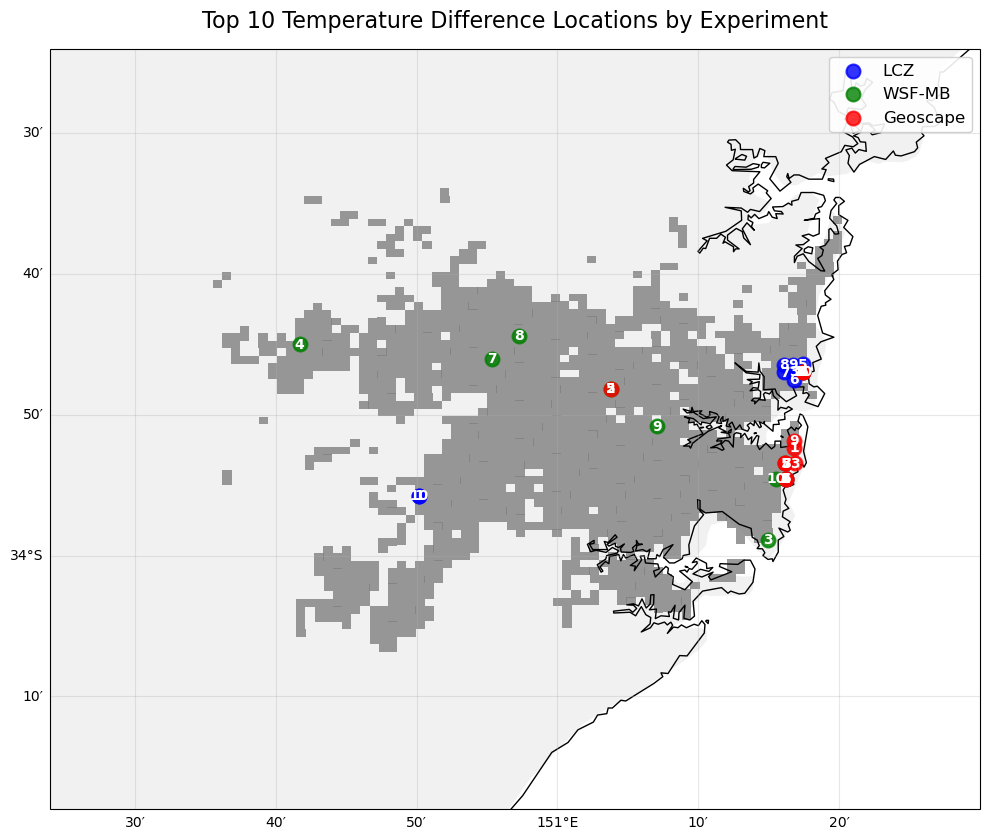

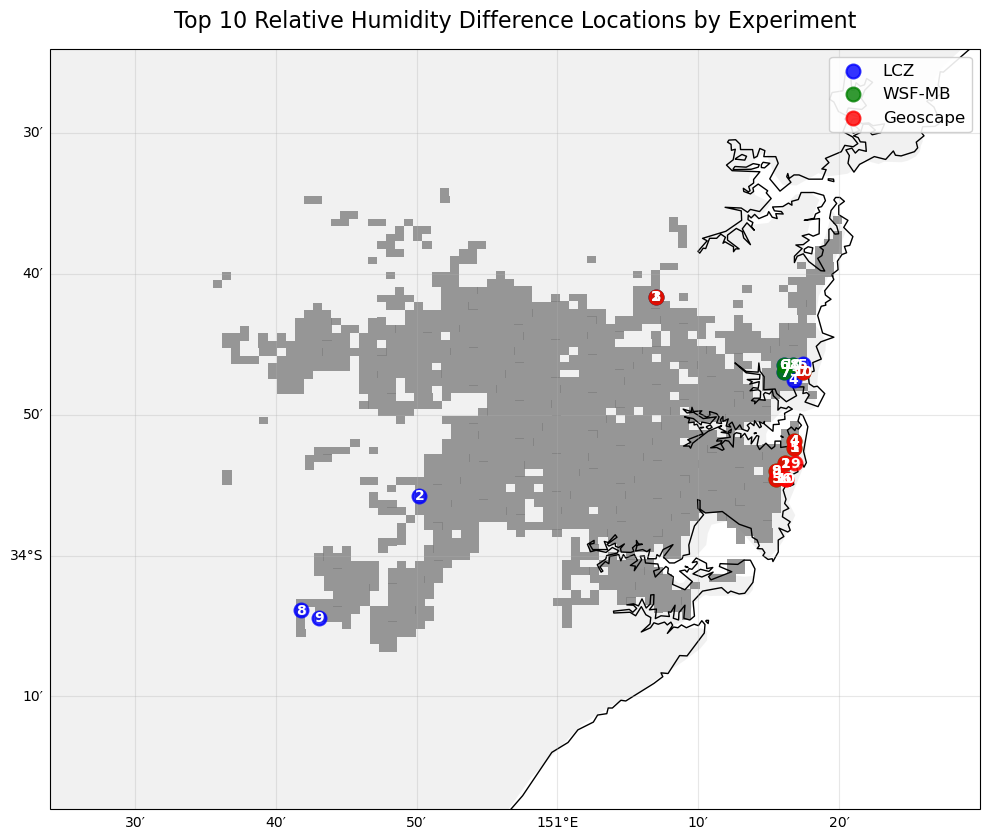

In [ ]:
#plot
# Define file path and domain boundaries
file_luindex = "/g/data/fy29/mf9078/run_WRF/etamodified/output/4out/animation/wrfout_d02_2017-01-12_21:00:00"
# mask
lat_min_mask, lat_max_mask = -34.14, -33.55
lon_min_mask, lon_max_mask = 150.57, 151.37

# Load the geo_em file
ds = xr.open_dataset(file_luindex)

# Get coordinates and select first time step (if there's a time dimension)
XLAT = ds["XLAT"].isel(Time=0) if "Time" in ds["XLAT"].dims else ds["XLAT"]
XLONG = ds["XLONG"].isel(Time=0) if "Time" in ds["XLONG"].dims else ds["XLONG"]
LU_INDEX = ds["LU_INDEX"].isel(Time=0) if "Time" in ds["LU_INDEX"].dims else ds["LU_INDEX"]

# Create masks
lat_mask = (XLAT >= lat_min_mask) & (XLAT <= lat_max_mask)
lon_mask = (XLONG >= lon_min_mask) & (XLONG <= lon_max_mask)
lu_mask = (LU_INDEX >= 51) & (LU_INDEX <= 60)
region_mask = lat_mask & lon_mask & lu_mask

# Get data and select first time step if needed
lu_data = ds["LU_INDEX"].isel(Time=0) if "Time" in ds["LU_INDEX"].dims else ds["LU_INDEX"]
lu = lu_data.where(region_mask)

# Plot extent
lat_min, lat_max = -34.3, -33.4
lon_min, lon_max = 150.4, 151.5

# Create a single-color colormap for grey
grey_cmap = ListedColormap(['grey'])

# Color mapping for experiments
exp_colors = {
    "LCZ": 'blue',
    "WSF-MB": 'green',
    "Geoscape": 'red'
}

# Create figure
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([lon_min, lon_max, lat_min, lat_max])

# Add map features
ax.add_feature(cfeature.GSHHSFeature(scale="h"))
ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.3)

# Plot urban areas
mesh = ax.pcolormesh(XLONG, XLAT, lu, transform=ccrs.PlateCarree(), 
                     alpha=0.8, shading='nearest', cmap=grey_cmap)

# Plot top 5 points for each experiment (for Temperature)
for exp in experiments:
    top_5 = top_T_results[exp]
    
    # Plot each point
    ax.scatter(top_5['XLONG'], top_5['XLAT'], 
              c=exp_colors[exp], 
              s=100,  # marker size
              marker='o',
              #edgecolors='black',
              linewidths=1.5,
              alpha=0.8,
              label=exp,
              transform=ccrs.PlateCarree(),
              zorder=5)
    
    # Add rank numbers on the points
    for idx, row in top_5.iterrows():
        ax.text(row['XLONG'], row['XLAT'], str(idx+1),
               fontsize=10, 
               ha='center', 
               va='center',
               color='white',
               fontweight='bold',
               transform=ccrs.PlateCarree(),
               zorder=6)

# Add gridlines
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, alpha=0.3)
gl.top_labels = False
gl.right_labels = False

# Add legend
ax.legend(loc='upper right', fontsize=12, framealpha=0.9)

# Labels and title
ax.set_title("Top 10 Temperature Difference Locations by Experiment", 
            fontsize=16, pad=15) #, fontweight='bold'

plt.tight_layout()
plt.savefig("/g/data/gb02/mf9078/plots/top_10_temp_diffs.png", dpi=300, bbox_inches='tight')
plt.show()

# Create a similar plot for RH2
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([lon_min, lon_max, lat_min, lat_max])

# Add map features
ax.add_feature(cfeature.GSHHSFeature(scale="h"))
ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.3)

# Plot urban areas
mesh = ax.pcolormesh(XLONG, XLAT, lu, transform=ccrs.PlateCarree(), 
                     alpha=0.8, shading='nearest', cmap=grey_cmap)

# Plot top 5 points for each experiment (for RH2)
for exp in experiments:
    top_5 = top_RH_results[exp]
    
    # Plot each point
    ax.scatter(top_5['XLONG'], top_5['XLAT'], 
              c=exp_colors[exp], 
              s=100,
              marker='o',
              #edgecolors='black',
              linewidths=1.5,
              alpha=0.8,
              label=exp,
              transform=ccrs.PlateCarree(),
              zorder=5)
    
    # Add rank numbers on the points
    for idx, row in top_5.iterrows():
        ax.text(row['XLONG'], row['XLAT'], str(idx+1),
               fontsize=10, 
               ha='center', 
               va='center',
               color='white',
               fontweight='bold',
               transform=ccrs.PlateCarree(),
               zorder=6)

# Add gridlines
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, alpha=0.3)
gl.top_labels = False
gl.right_labels = False

# Add legend
ax.legend(loc='upper right', fontsize=12, framealpha=0.9)

# Labels and title
ax.set_title("Top 10 Relative Humidity Difference Locations by Experiment", 
            fontsize=16, pad=15)  #, fontweight='bold'

plt.tight_layout()
plt.savefig("/g/data/gb02/mf9078/plots/top_10_rh_diffs.png", dpi=300, bbox_inches='tight')
plt.show()

Extract T and RH from WRF files at all times and all urban locations and calculating their differences with those from Geoscape

In [11]:
#code to extract variables of interest from LCZ, WSF3DMSB, and Geoscape cases

# Constants
#Rd = 287.05  # J/kg/K

vars = ['T', 'RH2']

# file paths
paths = {
    "Default(Bulk+NoUCM)": "/g/data/fy29/mf9078/run_WRF/etamodified/output/0out/animation/",
    "LCZ": "/g/data/fy29/mf9078/run_WRF/etamodified/output/1out/animation/",
    "WSF-MB": "/g/data/fy29/mf9078/run_WRF/etamodified/output/3out/animation/",
    "Geoscape": "/g/data/fy29/mf9078/run_WRF/etamodified/output/4out/animation/"
}

# Dictionary to store results for each scenario, period, and variable
results = {}
results['time']=[]
for label, sc_path in paths.items():
    results[label] = {}
    for var in vars:
        results[label][var]=[]

# Loop through all the scenarios
for label, sc_path in paths.items():
    file_list = sorted(glob.glob(os.path.join(sc_path, "wrfout_d02_2017-01-*")))
      
    # Loop through files
    for fpath in file_list:
        ds = xr.open_dataset(fpath)
        ncfile = Dataset(fpath)
        
        # Parse timestamp and convert to AEST
        timestamp_utc = datetime.strptime(os.path.basename(fpath)[11:], "%Y-%m-%d_%H:%M:%S")
        timestamp_aest = timestamp_utc + timedelta(hours=10)
        
        #diagnostic variable RH2
        rh2 = getvar(ncfile, "rh2")
            
        variables = {
            'T': ds["T2"], 
            'RH2': rh2,
        }
                
        if label == 'LCZ': #just for one case
            results['time'].append(timestamp_aest)
        for key, val in variables.items():
            results[label][key].append(val)

with open("/g/data/gb02/mf9078/WRF_TRHscatter.pkl", "wb") as f:
    pickle.dump(results, f)

In [12]:
# mask
lat_min, lat_max = -34.14, -33.55
lon_min, lon_max = 150.57, 151.37

file_luindex = "/g/data/fy29/mf9078/run_WRF/etamodified/output/4out/animation/wrfout_d02_2017-01-12_21:00:00" #any wrfout with 10-category LCZ, i.e., any scenario but bulk

# Initialize on first file to get the subset bounds and mask
ds = xr.open_dataset(file_luindex) 
XLAT = ds["XLAT"]
XLONG = ds["XLONG"]
LU_INDEX = ds["LU_INDEX"]

lat_mask = (XLAT >= lat_min) & (XLAT <= lat_max)
lon_mask = (XLONG >= lon_min) & (XLONG <= lon_max)
lu_mask = (LU_INDEX >= 51) & (LU_INDEX <= 60)
region_mask = lat_mask & lon_mask & lu_mask

In [ ]:
#calculate differences with the Geoscape case
experiments = {"Default(Bulk+NoUCM)", "LCZ", "WSF-MB"}
vars= {'T','RH2'}
#because of the mismatch in dimensions of RH2 (acquired by getvar) and T, create 2 different dics
diff_data_RH={}
diff_data_T={}
diff_data_T['time']=results['time']
diff_data_RH['time']=results['time']
for exp in experiments:
    diff_data_RH[exp]=[]
    diff_data_T[exp]=[]

for exp in experiments:
    for i in range(len(results['Default(Bulk+NoUCM)']['RH2'])): #any list
        diff_T = results[exp]['T'][i].where(region_mask) - results["Geoscape"]['T'][i].where(region_mask)
        exp_RH = results[exp]['RH2'][i]
        default_RH = results["Geoscape"]['RH2'][i]
        diff_RH_unmasked = exp_RH - default_RH
        diff_RH = diff_RH_unmasked.where(region_mask)
        diff_data_T[exp].append(diff_T)
        diff_data_RH[exp].append(diff_RH)

with open("/g/data/gb02/mf9078/WRF_Tdiffscatter_Geoscape.pkl", "wb") as f:
    pickle.dump(diff_data_T, f)

with open("/g/data/gb02/mf9078/WRF_RHdiffscatter_Geoscape.pkl", "wb") as f:
    pickle.dump(diff_data_RH, f)